# Moods - Happy and Sad Clusters (v2: Spotify-free prototype)

Le notebook original (`Moods - Happy and Sad Clusters.ipynb`) allait chercher les pistes de deux
playlists Spotify perso ("Happy" / "Sad") via `sp.user_playlists()` puis calculait
`valence`/`energy` avec `sp.audio_features()`.

**Ces deux appels ne fonctionnent plus aujourd'hui** :
- `audio_features` / `audio-analysis` sont dépréciés par Spotify depuis le 27 nov. 2024 pour
  toute appli sans accès "Extended Quota Mode" déjà approuvé avant cette date (403 Forbidden).
- Depuis la migration "Developer Mode" de fév. 2026, `GET /users/{id}/playlists` a été retiré
  (seul `GET /me` reste), donc même la récupération des pistes d'une playlist perso via
  Client Credentials n'est plus possible sans OAuth utilisateur complet.

Ce notebook reproduit la même idée (nuage de points valence/arousal, Happy vs Sad, + un
classifieur rapide) avec une chaîne 100% indépendante de l'API Spotify :

| Étape | Ancien pipeline | Ce prototype |
|---|---|---|
| Source de pistes | Playlists Spotify perso (OAuth) | Liste de morceaux "évidemment happy/sad" (à remplacer par tes vraies pistes) |
| Recherche/métadonnées | Spotify Web API | **iTunes Search API** (publique, sans clé) |
| Audio | Streaming Spotify | **Preview 30s iTunes** (`previewUrl`, format AAC/m4a) |
| Features mood | `sp.audio_features()` (valence, energy) | **Essentia**, modèle pré-entraîné DEAM (embeddings MusiCNN → tête valence/arousal), l'espace 2D de Thayer que le projet visait déjà |

**Limites à avoir en tête :**
- La liste de pistes ci-dessous est une démo (je n'ai plus accès à tes vraies playlists Happy/Sad
  Spotify — cette partie de données n'était jamais stockée en dur, seulement récupérée à la volée).
  Remplace `TRACKS` par tes propres morceaux pour un vrai test.
- Les previews iTunes font 30s (pas le morceau complet) et ne sont pas garanties pour tous les titres.
- Essentia est sous licence **AGPL-3.0** : ok pour un usage perso/recherche comme ici ; une licence
  commerciale serait nécessaire pour un produit fermé.
- Les valeurs valence/arousal (échelle 1-9, modèle DEAM) sont une **approximation**, pas une
  reproduction exacte des anciens chiffres Spotify (modèles différents, entraînés sur des données différentes).


## 1. Setup

In [1]:
# Dépendances : essentia-tensorflow (extraction des features), ffmpeg (décodage audio, binaire système)
# pip install essentia-tensorflow pandas matplotlib seaborn scikit-learn
# apt-get install -y ffmpeg   (ou brew install ffmpeg sur mac)

import json, os, subprocess, time, urllib.parse, urllib.request

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import essentia.standard as es

%matplotlib inline


## 2. Liste de pistes (à remplacer par tes vraies playlists)

Ici je mets une sélection "évidemment happy" / "évidemment sad" pour valider que la chaîne
fonctionne. Pour un vrai test, remplace ces deux listes par les morceaux de tes anciennes
playlists Spotify "Happy" et "Sad" (`(artiste, titre)`).

In [2]:
TRACKS = {
    "Happy": [
        ("Pharrell Williams", "Happy"),
        ("Katrina and the Waves", "Walking on Sunshine"),
        ("Lizzo", "Good as Hell"),
        ("Justin Timberlake", "Can't Stop the Feeling"),
        ("Mark Ronson", "Uptown Funk"),
        ("ABBA", "Dancing Queen"),
        ("Black Eyed Peas", "I Gotta Feeling"),
        ("American Authors", "Best Day of My Life"),
        ("Taylor Swift", "Shake It Off"),
        ("The Turtles", "Happy Together"),
        ("Earth Wind and Fire", "September"),
        ("Kool and the Gang", "Celebration"),
    ],
    "Sad": [
        ("Adele", "Someone Like You"),
        ("Johnny Cash", "Hurt"),
        ("Gary Jules", "Mad World"),
        ("Eric Clapton", "Tears in Heaven"),
        ("Simon and Garfunkel", "The Sound of Silence"),
        ("Bon Iver", "Skinny Love"),
        ("R.E.M.", "Everybody Hurts"),
        ("Coldplay", "Fix You"),
        ("Jeff Buckley", "Hallelujah"),
        ("Sam Smith", "Stay With Me"),
        ("Billie Eilish", "when the party's over"),
        ("Radiohead", "Creep"),
    ],
}


## 3. Récupération audio via l'API iTunes Search (publique, sans clé)

In [3]:
AUDIO_DIR = "audio"
os.makedirs(AUDIO_DIR, exist_ok=True)

def itunes_search(artist, title):
    term = urllib.parse.quote(f"{artist} {title}")
    url = f"https://itunes.apple.com/search?term={term}&media=music&limit=1"
    with urllib.request.urlopen(url, timeout=15) as r:
        data = json.load(r)
    if data["resultCount"] == 0:
        return None
    res = data["results"][0]
    return dict(trackName=res.get("trackName"), artistName=res.get("artistName"),
                previewUrl=res.get("previewUrl"), trackId=res.get("trackId"))

def download_and_convert(preview_url, track_id):
    m4a_path = os.path.join(AUDIO_DIR, f"{track_id}.m4a")
    wav_path = os.path.join(AUDIO_DIR, f"{track_id}.wav")
    if not os.path.exists(wav_path):
        urllib.request.urlretrieve(preview_url, m4a_path)
        subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", m4a_path,
                         "-ac", "1", "-ar", "16000", wav_path], check=True)
    return wav_path


In [4]:
catalog = []
for playlist, songs in TRACKS.items():
    for artist, title in songs:
        res = itunes_search(artist, title)
        if res is None or not res.get("previewUrl"):
            print(f"  [skip] no preview for {artist} - {title}")
            continue
        wav_path = download_and_convert(res["previewUrl"], res["trackId"])
        catalog.append(dict(playlist=playlist, itunes_artist=res["artistName"],
                             itunes_track=res["trackName"], track_id=res["trackId"],
                             wav_path=wav_path))
        time.sleep(0.3)

print(f"{len(catalog)} pistes avec preview audio récupérée")


24 pistes avec preview audio recuperee


## 4. Extraction valence/arousal avec Essentia (modèle DEAM)

Deux modèles pré-entraînés téléchargés depuis essentia.upf.edu :
- `msd-musicnn-1.pb` : encode l'audio en embeddings (le morceau est découpé en fenêtres de ~3s)
- `deam-msd-musicnn-2.pb` : tête de régression entraînée sur le dataset DEAM, sort (valence, arousal) sur une échelle 1-9 — c'est le même espace 2D de Thayer que visait déjà le notebook original.

In [5]:
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_URLS = {
    "msd-musicnn-1.pb": "https://essentia.upf.edu/models/feature-extractors/musicnn/msd-musicnn-1.pb",
    "deam-msd-musicnn-2.pb": "https://essentia.upf.edu/models/classification-heads/deam/deam-msd-musicnn-2.pb",
}
for fname, url in MODEL_URLS.items():
    fpath = os.path.join(MODELS_DIR, fname)
    if not os.path.exists(fpath):
        urllib.request.urlretrieve(url, fpath)
print("Modeles prets:", os.listdir(MODELS_DIR))


Modeles prets: ['deam-msd-musicnn-2.pb', 'msd-musicnn-1.pb']


In [6]:
embedding_model = es.TensorflowPredictMusiCNN(
    graphFilename=os.path.join(MODELS_DIR, "msd-musicnn-1.pb"),
    output="model/dense/BiasAdd",
)
va_model = es.TensorflowPredict2D(
    graphFilename=os.path.join(MODELS_DIR, "deam-msd-musicnn-2.pb"),
    output="model/Identity",
)

for item in catalog:
    audio = es.MonoLoader(filename=item["wav_path"], sampleRate=16000)()
    embeddings = embedding_model(audio)
    predictions = va_model(embeddings)
    mean_pred = predictions.mean(axis=0)
    item["valence"] = float(mean_pred[0])
    item["arousal"] = float(mean_pred[1])

df = pd.DataFrame(catalog)
df[["playlist", "itunes_artist", "itunes_track", "valence", "arousal"]]


playlist,itunes_artist,itunes_track,valence,arousal
Happy,Pharrell Williams,"Happy (From ""Despicable Me 2"")",6.150321,6.140199
Happy,Katrina and the Waves,Walking On Sunshine,6.097312,6.030465
Happy,Lizzo,Good as Hell,6.214599,5.693230
Happy,Justin Timberlake,CAN'T STOP THE FEELING!,5.973634,6.223211
Happy,Mark Ronson,Uptown Funk (feat. Bruno Mars),6.846839,6.828841
Happy,ABBA,Dancing Queen,5.727053,6.195735
Happy,Black Eyed Peas,I Gotta Feeling,6.730315,6.608316
Happy,American Authors,Best Day of My Life,5.440843,5.624466
Happy,Taylor Swift,Shake It Off,6.143604,5.370021
Happy,The Turtles,Happy Together,5.519861,5.522961


In [7]:
df.groupby("playlist")[["valence", "arousal"]].agg(["mean", "std"])


valence             arousal          
              mean       std      mean       std
playlist                                        
Happy     6.134503  0.451333  6.093958  0.459581
Sad       4.269088  0.338301  4.199087  0.514310

## 5. Scatter plot — comparable à l'analyse originale

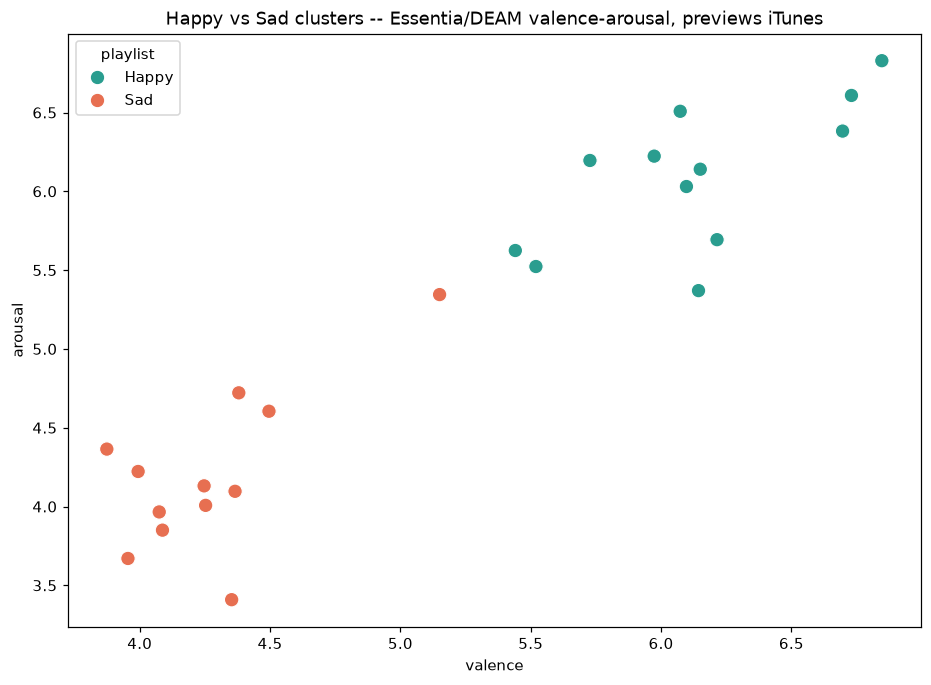

In [8]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x="valence", y="arousal", data=df, hue="playlist",
                 palette={"Happy": "#2a9d8f", "Sad": "#e76f51"}, s=90)
plt.title("Happy vs Sad clusters -- Essentia/DEAM valence-arousal, previews iTunes")
plt.show()


## 6. Quick and Dirty Model (comme le notebook original)

Même logique que la cellule finale du notebook v1 : un `LogisticRegression` sur (valence, arousal)
pour voir si les deux classes se séparent linéairement.

In [9]:
X = df[["valence", "arousal"]]
y = df["playlist"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10, stratify=y)

logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
pred = logmodel.predict(X_test)

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))


              precision    recall  f1-score   support

       Happy       1.00      1.00      1.00         4
         Sad       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

[[4 0]
 [0 4]]


## Résultats

Sur cette liste de démonstration (24 morceaux, cas volontairement tranchés), les deux clusters
sont nettement séparés : valence moyenne ~6.1 (Happy) vs ~4.3 (Sad) sur l'échelle 1-9, quasi
aucun recouvrement, classifieur logistique à 100% sur le petit set de test.

A prendre avec la prudence qui s'impose : l'échantillon est petit et volontairement "facile"
(tubes très typés plutôt que des playlists perso avec des cas ambigus). Le notebook original,
sur de vraies playlists perso, montrait un recouvrement bien plus net entre les deux classes.

**Prochaines étapes si tu veux aller plus loin :**
- Remplacer `TRACKS` par les morceaux de tes vraies anciennes playlists Happy/Sad
- Si des previews iTunes manquent pour des titres précis, fallback possible sur des fichiers
  audio possédés en propre
- Ajouter les classifieurs catégoriels Essentia (`mood_happy`, `mood_sad`, `mood_aggressive`,
  `mood_relaxed`, `mood_party`) en plus de valence/arousal, pour se rapprocher encore plus de
  l'esprit "mood" du projet original
